<a href="https://colab.research.google.com/github/Dhruv0956/motorq-projects/blob/main/Exoplanets/TIC%20441738827.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install lightkurve
!pip innstall oktopus

ERROR: unknown command "innstall" - maybe you meant "install"


In [ ]:
import lightkurve as lk

search = lk.search_targetpixelfile("TIC 441738827", mission="TESS")
print(search)

SearchResult containing 65 data products.

 #     mission     year   author  exptime target_name distance
                                     s                 arcsec 
--- -------------- ---- --------- ------- ----------- --------
  0 TESS Sector 16 2019      SPOC     120   441738827      0.0
  1 TESS Sector 19 2019      SPOC     120   441738827      0.0
  2 TESS Sector 20 2019      SPOC     120   441738827      0.0
  3 TESS Sector 21 2020      SPOC     120   441738827      0.0
  4 TESS Sector 22 2020      SPOC     120   441738827      0.0
  5 TESS Sector 23 2020      SPOC     120   441738827      0.0
  6 TESS Sector 25 2020      SPOC     120   441738827      0.0
  7 TESS Sector 26 2020      SPOC     120   441738827      0.0
  8 TESS Sector 48 2022      SPOC     120   441738827      0.0
  9 TESS Sector 49 2022      SPOC     120   441738827      0.0
 10 TESS Sector 50 2022      SPOC     120   441738827      0.0
 11 TESS Sector 51 2022      SPOC     120   441738827      0.0
 12 TESS Sec

In [ ]:
tpf = search[57].download()

In [ ]:
print(tpf)
print(tpf.path)

TessTargetPixelFile(TICID: 441738827)
/root/.lightkurve/cache/mastDownload/HLSP/hlsp_tess-spoc_tess_phot_0000000441738827-s0077_tess_v1_tp/hlsp_tess-spoc_tess_phot_0000000441738827-s0077_tess_v1_tp.fits


In [ ]:
from astropy.io import fits

hdul = fits.open(tpf.path)
hdul.info()

Filename: /root/.lightkurve/cache/mastDownload/HLSP/hlsp_tess-spoc_tess_phot_0000000441738827-s0077_tess_v1_tp/hlsp_tess-spoc_tess_phot_0000000441738827-s0077_tess_v1_tp.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      44   ()      
  1  PIXELS        1 BinTableHDU    248   12125R x 11C   [D, E, J, 121J, 121E, 121E, 121E, 121E, J, E, E]   
  2  APERTURE      1 ImageHDU        49   (11, 11)   int32   
  3  TARGET COSMIC RAY    1 BinTableHDU     27   0R x 4C   [J, I, I, E]   


In [ ]:
pixels = hdul[1].data

print(pixels.columns)

ColDefs(
    name = 'TIME'; format = 'D'; unit = 'BJD - 2457000, days'; disp = 'D14.7'
    name = 'TIMECORR'; format = 'E'; unit = 'd'; disp = 'E14.7'
    name = 'CADENCENO'; format = 'J'; disp = 'I10'
    name = 'RAW_CNTS'; format = '121J'; unit = 'count'; null = -1; disp = 'I8'; dim = '(11,11)'
    name = 'FLUX'; format = '121E'; unit = 'e-/s'; disp = 'E14.7'; dim = '(11,11)'
    name = 'FLUX_ERR'; format = '121E'; unit = 'e-/s'; disp = 'E14.7'; dim = '(11,11)'
    name = 'FLUX_BKG'; format = '121E'; unit = 'e-/s'; disp = 'E14.7'; dim = '(11,11)'
    name = 'FLUX_BKG_ERR'; format = '121E'; unit = 'e-/s'; disp = 'E14.7'; dim = '(11,11)'
    name = 'QUALITY'; format = 'J'; disp = 'B16.16'
    name = 'POS_CORR1'; format = 'E'; unit = 'pixel'; disp = 'E14.7'
    name = 'POS_CORR2'; format = 'E'; unit = 'pixel'; disp = 'E14.7'
)


In [ ]:
print(pixels["FLUX"].shape)
print(pixels["TIME"].shape)
print(hdul[2].data.shape)

(12125, 11, 11)
(12125,)
(11, 11)


In [ ]:
print(pixels["FLUX"][0])

[[145.26988  258.35858  158.2348   107.71297   84.26844   80.83581
   79.47606   80.051056  79.89135   80.63      86.31952 ]
 [109.340836 126.88633  122.04148  120.57233   87.12347   80.22968
   79.70394   79.70925   78.855415  79.37358   80.1798  ]
 [ 85.16976   90.768425  92.58871   89.50102   84.92296   80.58088
   79.170006  80.61506   79.16204   78.52802   78.08754 ]
 [ 82.65109   80.73481   82.63937   83.20265   88.3397    94.92803
   87.139626  79.07978   80.60252   78.18159   78.84458 ]
 [ 80.39231   78.38155   79.51788   85.083595 107.29768  163.53548
  131.32909   88.85507   82.8527    81.0553    80.33064 ]
 [ 80.86148   79.476395  79.540726  87.96739  122.121124 267.55176
  166.35231   93.60665   87.28594   90.7684    91.79342 ]
 [ 81.950966  78.50446   79.1736    83.01796   99.92299  133.26726
  117.77242   89.08708   85.48659   90.42194   91.51731 ]
 [ 79.83346   78.66939   81.80343   84.86529   85.9501    97.872925
   95.108795  85.87764   83.73111   84.72359   82.51372 ]

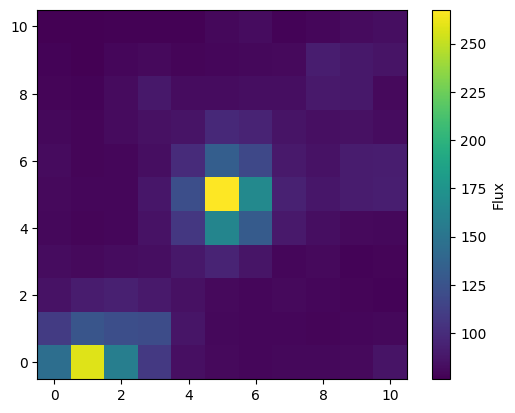

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(pixels["FLUX"][0], origin="lower")
plt.colorbar(label="Flux")
plt.show()

[65 69 75]


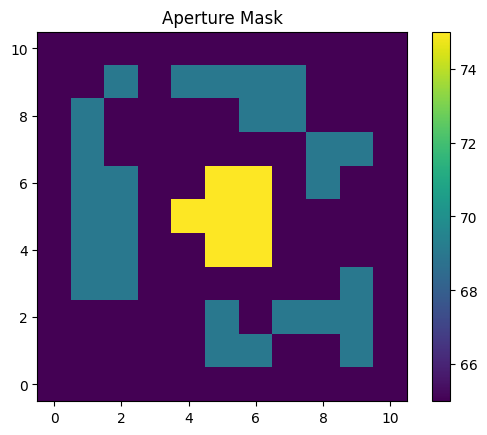

In [ ]:
import numpy as np

aperture = hdul[2].data

print(np.unique(aperture))

plt.imshow(aperture, origin="lower")
plt.colorbar()
plt.title("Aperture Mask")
plt.show()

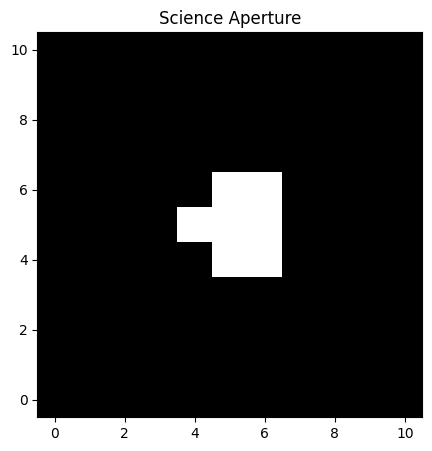

In [ ]:
science_mask = (aperture == 75)

plt.figure(figsize=(5,5))
plt.imshow(science_mask, origin="lower", cmap="gray")
plt.title("Science Aperture")
plt.show()


In [ ]:
image = pixels["FLUX"][0]

flux = image[science_mask].sum()

print(flux)

1101.9294


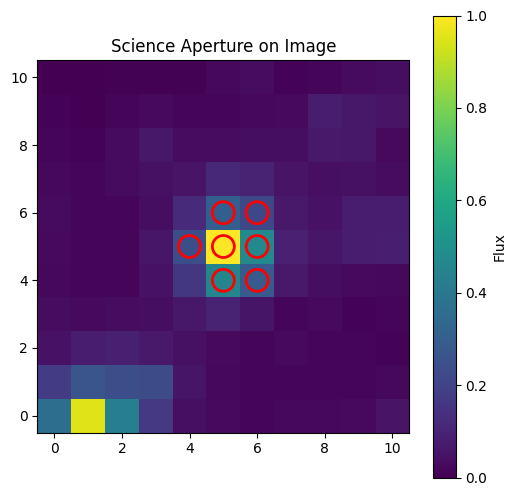

In [ ]:
plt.figure(figsize=(6,6))

plt.imshow(image, origin="lower", cmap="viridis")

y, x = np.where(science_mask)

plt.scatter(x, y,
            facecolors='none',
            edgecolors='red',
            s=250,
            linewidths=2)

plt.colorbar(label="Flux")
plt.title("Science Aperture on Image")
plt.show()

In [ ]:
import numpy as np

def aperture_photometry(image, mask):
    """
    Sum all pixels inside the aperture.
    """

    return np.sum(image[mask])

In [ ]:
fluxes = []

for image in pixels["FLUX"]:
    fluxes.append(aperture_photometry(image, science_mask))
fluxes = np.array(fluxes)

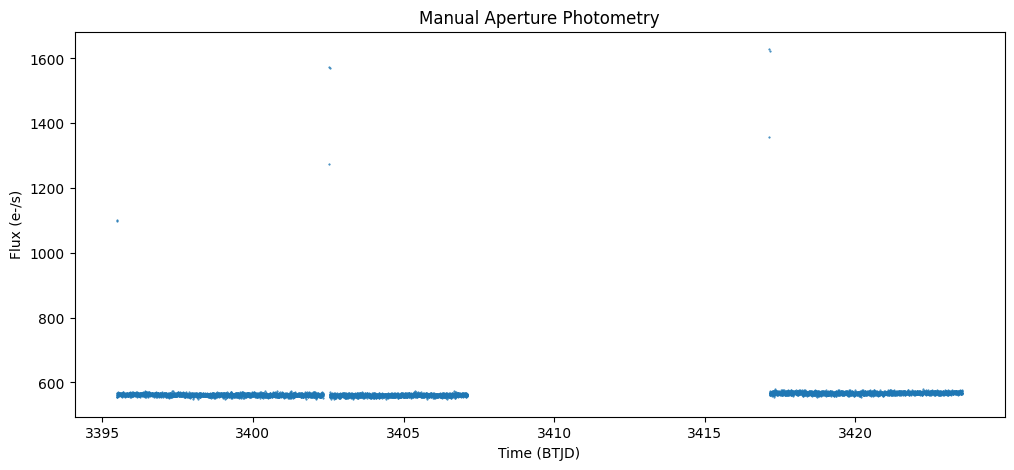

In [ ]:
time = pixels["TIME"]

plt.figure(figsize=(12,5))

plt.plot(time, fluxes, ".", ms=1)

plt.xlabel("Time (BTJD)")
plt.ylabel("Flux (e-/s)")

plt.title("Manual Aperture Photometry")

plt.show()

In [ ]:
np.isnan(fluxes).sum()
np.isinf(fluxes).sum()
fluxes.min(), fluxes.max()
fluxes.mean()
print(fluxes.shape)
print(fluxes.min(), fluxes.max(), fluxes.mean())

(12125,)
nan nan nan


In [ ]:
# Manual Custom Aperture
import numpy as np

def threshold_aperture(image, threshold):
    return image > threshold

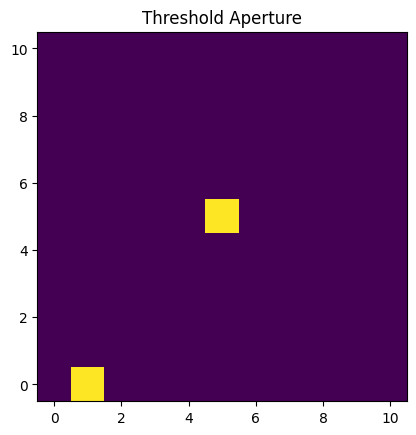

In [ ]:
mask = threshold_aperture(image, 120)

plt.imshow(mask, origin="lower")
plt.title("Threshold Aperture")
plt.show()

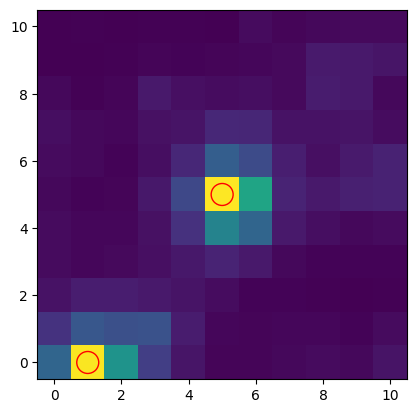

In [ ]:
plt.imshow(image, origin="lower")

y, x = np.where(mask)

plt.scatter(
    x,
    y,
    facecolors="none",
    edgecolors="red",
    s=250
)

plt.show()

In [ ]:
import numpy as np

image = pixels["FLUX"][0]

seed = np.unravel_index(
    np.argmax(image),
    image.shape
)

print(seed)

(np.int64(5), np.int64(5))


In [ ]:
threshold = 120
candidate = image > threshold

mask = np.zeros_like(candidate, dtype=bool)

In [ ]:
def get_neighbors(row, col, shape):
    rows, cols = shape
    neighbors = []
    # Define relative offsets for 8-way connectivity (including diagonals)
    # Use [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)] for 8-way
    # Use [(-1, 0), (1, 0), (0, -1), (0, 1)] for 4-way (cardinal)
    offsets = [(-1, -1), (-1, 0), (-1, 1),
               (0, -1),           (0, 1),
               (1, -1),  (1, 0),  (1, 1)]

    for dr, dc in offsets:
        nr, nc = row + dr, col + dc
        # Check boundaries
        if 0 <= nr < rows and 0 <= nc < cols:
            neighbors.append((nr, nc))
    return neighbors

In [ ]:
from collections import deque
import numpy as np

def connected_aperture(candidate, seed):
    rows, cols = candidate.shape

    mask = np.zeros_like(candidate, dtype=bool)
    visited = np.zeros_like(candidate, dtype=bool)

    queue = deque([seed])
    visited[seed] = True

    while queue:
        r, c = queue.popleft()

        if not candidate[r, c]:
            continue

        mask[r, c] = True

        for nr, nc in get_neighbors(r, c, candidate.shape):
            if not visited[nr, nc]:
                visited[nr, nc] = True
                queue.append((nr, nc))

    return mask

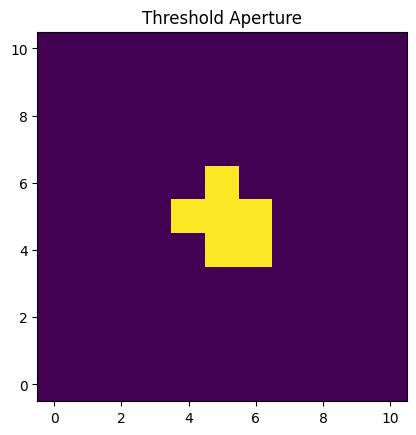

In [ ]:
mask = connected_aperture(candidate, (5,5))

plt.imshow(mask, origin="lower")
plt.title("Threshold Aperture")
plt.show()

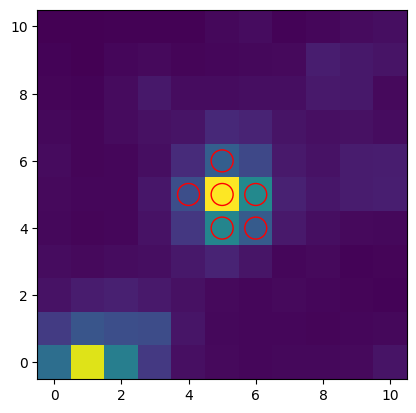

In [ ]:
plt.imshow(image, origin="lower")

y, x = np.where(mask)

plt.scatter(
    x,
    y,
    facecolors="none",
    edgecolors="red",
    s=250
)

plt.show()

In [ ]:
from astropy.wcs import WCS

wcs = WCS(hdul[2].header)

print(wcs)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN'
CUNIT : 'deg' 'deg'
CRVAL : 259.25493086442424 72.74711270705713
CRPIX : 6.238288865290656 6.027355676645584
PC1_1 PC1_2  : -0.4886240681355105 -0.8597181036796588
PC2_1 PC2_2  : -0.8711289061872849 0.5138402405558566
CDELT : -0.0056881171878553 0.0056881171878553
NAXIS : 11  11


In [ ]:
from astropy.coordinates import SkyCoord
import astropy.units as u

center = wcs.pixel_to_world(5, 5)

print(center)

<SkyCoord (ICRS): (ra, dec) in deg
    (259.25224665, 72.74821348)>


In [ ]:
import numpy as np

def centroid(image, mask=None, background=0):
    """
    Intensity-weighted centroid after background subtraction.
    """

    working = image.astype(float) - background

    # Don't allow negative flux to pull the centroid
    working[working < 0] = 0

    if mask is not None:
        working = working * mask

    y, x = np.indices(working.shape)

    total = working.sum()

    if total == 0:
        return None

    x_c = (x * working).sum() / total
    y_c = (y * working).sum() / total

    return y_c, x_c

In [ ]:
print(pixels["FLUX_ERR"][0])

[[1.1031405  1.4043875  1.1378256  0.9784737  0.9055871  0.8860216
  0.88324815 0.8805985  0.87941056 0.88533795 0.9025672 ]
 [0.9896902  1.0385622  1.029006   1.0257844  0.9178489  0.8745919
  0.88142896 0.8818267  0.87777483 0.88642997 0.8751391 ]
 [0.9084326  0.9199096  0.9303986  0.92332745 0.9042102  0.8799077
  0.8766853  0.878797   0.87299347 0.8885578  0.8677739 ]
 [0.9001283  0.88234466 0.8850385  0.892168   0.9226544  0.93591803
  0.9099199  0.8810581  0.8882735  0.8835332  0.88019246]
 [0.88009804 0.875857   0.8801005  0.8979608  0.9897962  1.149494
  1.0570897  0.9196882  0.8884752  0.8955889  0.88203007]
 [0.89040333 0.8733199  0.87587464 0.9190783  1.0413471  1.4204675
  1.1538191  0.93090904 0.9044844  0.92842025 0.92410636]
 [0.8970198  0.8811941  0.8760619  0.89477587 0.9697894  1.0579807
  1.0091096  0.9176837  0.90689063 0.92931604 0.92571414]
 [0.88888776 0.87877196 0.8854395  0.9001402  0.9096327  0.9436725
  0.9309998  0.905502   0.89771175 0.91059923 0.8957242 ]


In [ ]:
print(pixels["FLUX"][0])

[[145.26988  258.35858  158.2348   107.71297   84.26844   80.83581
   79.47606   80.051056  79.89135   80.63      86.31952 ]
 [109.340836 126.88633  122.04148  120.57233   87.12347   80.22968
   79.70394   79.70925   78.855415  79.37358   80.1798  ]
 [ 85.16976   90.768425  92.58871   89.50102   84.92296   80.58088
   79.170006  80.61506   79.16204   78.52802   78.08754 ]
 [ 82.65109   80.73481   82.63937   83.20265   88.3397    94.92803
   87.139626  79.07978   80.60252   78.18159   78.84458 ]
 [ 80.39231   78.38155   79.51788   85.083595 107.29768  163.53548
  131.32909   88.85507   82.8527    81.0553    80.33064 ]
 [ 80.86148   79.476395  79.540726  87.96739  122.121124 267.55176
  166.35231   93.60665   87.28594   90.7684    91.79342 ]
 [ 81.950966  78.50446   79.1736    83.01796   99.92299  133.26726
  117.77242   89.08708   85.48659   90.42194   91.51731 ]
 [ 79.83346   78.66939   81.80343   84.86529   85.9501    97.872925
   95.108795  85.87764   83.73111   84.72359   82.51372 ]

In [ ]:
from dataclasses import dataclass

@dataclass
class PhotometryResult:
    flux: float
    flux_error: float
    n_pixels: int

def measure_flux(image, flux_err, aperture_mask, background=0.0):
    """
    Measure aperture flux and its uncertainty for a single cadence.

    Parameters
    ----------
    image : (H, W) ndarray
        Flux image (e-/s).

    flux_err : (H, W) ndarray
        1-sigma uncertainty image corresponding to `image`.

    aperture_mask : (H, W) ndarray of bool
        Pixels belonging to the source aperture.

    background : float or ndarray, optional
        Background level (scalar or image) to subtract before summing.

    Returns
    -------
    result : dict
        {
            "flux": float,
            "flux_error": float,
            "n_pixels": int
        }
    """

    image = np.asarray(image, dtype=float)
    flux_err = np.asarray(flux_err, dtype=float)
    aperture_mask = np.asarray(aperture_mask, dtype=bool)

    if image.shape != flux_err.shape:
        raise ValueError("image and flux_err must have the same shape.")

    if image.shape != aperture_mask.shape:
        raise ValueError("aperture_mask must have the same shape as image.")

    # Background subtraction
    signal = image - background

    # Aperture flux
    flux = signal[aperture_mask].sum()

    # Variance propagation
    variance = np.square(flux_err[aperture_mask]).sum()

    flux_error = np.sqrt(variance)

    return PhotometryResult(
      flux=flux,
      flux_error=flux_error,
      n_pixels=aperture_mask.sum()
    )

In [ ]:
times = []
fluxes = []
flux_errors = []

for time, image, error, quality in zip(
    pixels["TIME"],
    pixels["FLUX"],
    pixels["FLUX_ERR"],
    pixels["QUALITY"],
):

    valid = (
        quality == 0
        and np.isfinite(time)
        and np.isfinite(image).all()
        and np.isfinite(error).all()
    )

    if not valid:
        continue

    result = measure_flux(
        image=image,
        flux_err=error,
        aperture_mask=science_mask,
    )

    times.append(time)
    fluxes.append(result.flux)
    flux_errors.append(result.flux_error)

times = np.asarray(times)
fluxes = np.asarray(fluxes)
flux_errors = np.asarray(flux_errors)

In [ ]:
times = np.array(times)
fluxes = np.array(fluxes)
flux_errors = np.array(flux_errors)
print(times.shape)
print(fluxes.shape)
print(flux_errors.shape)

(7684,)
(7684,)
(7684,)


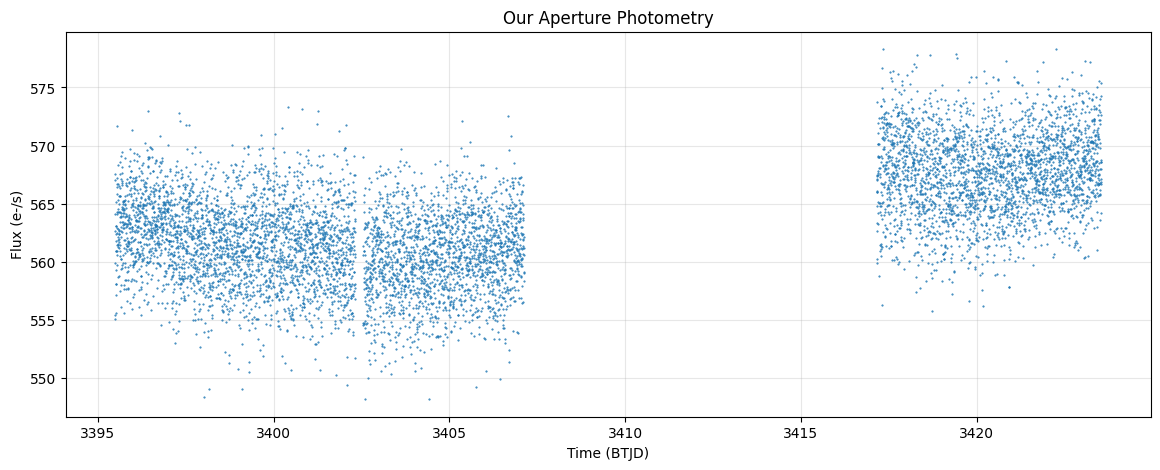

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(times, fluxes, ".", ms=1)

plt.xlabel("Time (BTJD)")
plt.ylabel("Flux (e-/s)")
plt.title("Our Aperture Photometry")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
print(f"Mean flux     : {np.mean(fluxes):.2f}")
print(f"Median flux   : {np.median(fluxes):.2f}")
print(f"Std deviation : {np.std(fluxes):.2f}")
print(f"Min flux      : {np.min(fluxes):.2f}")
print(f"Max flux      : {np.max(fluxes):.2f}")
print(pixels["QUALITY"][:30])
print(np.unique(pixels["QUALITY"]))

Mean flux     : 563.56
Median flux   : 563.34
Std deviation : 4.73
Min flux      : 548.20
Max flux      : 578.29
[40 32  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0]
[  0   8  32  40 128 160 164]


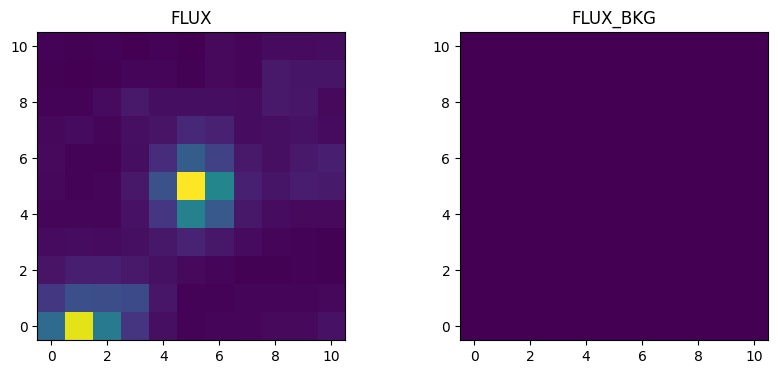

In [ ]:
i = 100

image = pixels["FLUX"][i]
background = pixels["FLUX_BKG"][i]

fig, ax = plt.subplots(1,2,figsize=(10,4))

ax[0].imshow(image, origin="lower")
ax[0].set_title("FLUX")

ax[1].imshow(background, origin="lower")
ax[1].set_title("FLUX_BKG")

plt.show()

In [ ]:
i = 100

image = pixels["FLUX"][i]
background = pixels["FLUX_BKG"][i]

print(image.min(), image.max())
print(background.min(), background.max())

print(np.nanmedian(background))
print(np.nanmean(background))
print(np.nanstd(background))

-0.7687409 194.21104
76.86847 76.86847
76.86847
76.86847
0.0


In [ ]:
from scipy.ndimage import median_filter

@dataclass
class LightCurve:
    """
    Simple light curve container.

    Parameters
    ----------
    time : ndarray
        Observation times (BTJD).

    flux : ndarray
        Flux measurements.

    flux_error : ndarray
        1-sigma uncertainties on the flux.
    """

    time: np.ndarray
    flux: np.ndarray
    flux_error: np.ndarray

    def __post_init__(self):
        """Ensure everything is stored as NumPy arrays."""
        self.time = np.asarray(self.time, dtype=float)
        self.flux = np.asarray(self.flux, dtype=float)
        self.flux_error = np.asarray(self.flux_error, dtype=float)

        if not (
            len(self.time)
            == len(self.flux)
            == len(self.flux_error)
        ):
            raise ValueError("time, flux, and flux_error must have the same length.")

    @property
    def n_points(self):
        """Number of data points."""
        return len(self.time)

    def statistics(self):
        """Print basic statistics of the light curve."""

        print(f"Number of points : {self.n_points}")
        print(f"Mean flux        : {np.mean(self.flux):.6f}")
        print(f"Median flux      : {np.median(self.flux):.6f}")
        print(f"Std deviation    : {np.std(self.flux):.6f}")
        print(f"Minimum flux     : {np.min(self.flux):.6f}")
        print(f"Maximum flux     : {np.max(self.flux):.6f}")

    def plot(self,
             show_errors=False,
             figsize=(12, 5),
             title="Light Curve",
             xlabel="Time (BTJD)",
             ylabel="Flux (e-/s)"):

        plt.figure(figsize=figsize)

        if show_errors:
            plt.errorbar(
                self.time,
                self.flux,
                yerr=self.flux_error,
                fmt=".",
                markersize=2,
                capsize=0,
            )
        else:
            plt.plot(
                self.time,
                self.flux,
                ".",
                markersize=2,
            )

        plt.xlabel("Time (BTJD)")
        plt.ylabel(ylabel)
        plt.title(title)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    def normalize(self):
        """
        Normalize the light curve by its median.

        Returns
        -------
        LightCurve
            A new normalized light curve.
        """

        median_flux = np.median(self.flux)

        return LightCurve(
            time=self.time.copy(),
            flux=self.flux / median_flux,
            flux_error=self.flux_error / median_flux,
        )

    def sigma_clip(self, sigma=5):
        """Return a sigma-clipped LightCurve."""
        median = np.median(self.flux)
        scatter = 1.4826 * np.median(np.abs(self.flux - median))  # Robust MAD estimate

        if scatter == 0:
            return LightCurve(
                time=self.time.copy(),
                flux=self.flux.copy(),
                flux_error=self.flux_error.copy(),
            )

        mask = np.abs(self.flux - median) < sigma * scatter

        return LightCurve(
            time=self.time[mask],
            flux=self.flux[mask],
            flux_error=self.flux_error[mask] if self.flux_error is not None else None,
        )

    def detrend(self, window=101):

        if window % 2 == 0:
            raise ValueError("window must be odd.")

        trend = median_filter(self.flux, size=window)

        detrended_flux = self.flux / trend

        return (
            LightCurve(
                time=self.time.copy(),
                flux=detrended_flux,
                flux_error=self.flux_error / trend,
            ),
            trend,
        )

    def fold(self, period, t0=None):
        """Fold the light curve on a given period."""
        if period <= 0:
            raise ValueError("period must be positive")

        if t0 is None:
            t0 = self.time[0]

        # Compute orbital phase (0 to 1)
        phase = ((self.time - t0) % period) / period

        # Sort by phase
        order = np.argsort(phase)

        return LightCurve(
            time=phase[order].copy(),
            flux=self.flux[order].copy(),
            flux_error=(
                self.flux_error[order].copy()
                if self.flux_error is not None
                else None
            ),
        )

In [ ]:
lc = LightCurve(time=times, flux=fluxes, flux_error=flux_errors)

Number of points : 7684
Mean flux        : 563.556101
Median flux      : 563.336695
Std deviation    : 4.729638
Minimum flux     : 548.203728
Maximum flux     : 578.288410


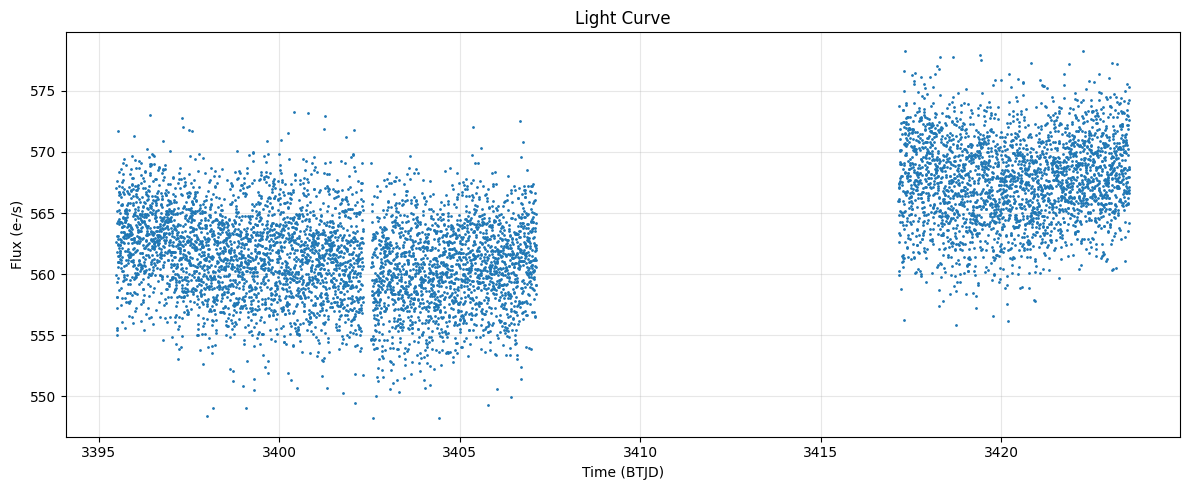

In [ ]:
lc.statistics()
lc.plot()

In [ ]:
normalized_lc = lc.normalize()

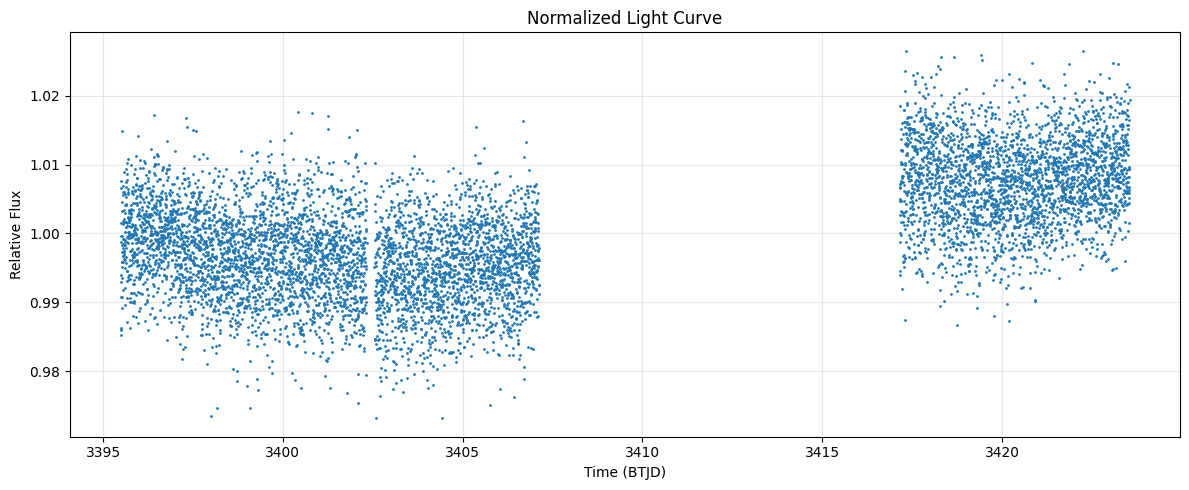

In [ ]:
normalized_lc.plot(
    title="Normalized Light Curve",
    ylabel="Relative Flux",
)

In [ ]:
normalized_lc.statistics()

Number of points : 7684
Mean flux        : 1.000389
Median flux      : 1.000000
Std deviation    : 0.008396
Minimum flux     : 0.973137
Maximum flux     : 1.026541


In [ ]:
print("science_mask pixels:", science_mask.sum())

image = pixels["FLUX"][0]
print("Max pixel:", image.max())
print("Sum all pixels:", image.sum())
print("Sum aperture:", image[science_mask].sum())

science_mask pixels: 7
Max pixel: 267.55176
Sum all pixels: 11082.202
Sum aperture: 1101.9294


Number of points : 7684
Mean flux        : 1.000389
Median flux      : 1.000000
Std deviation    : 0.008396
Minimum flux     : 0.973137
Maximum flux     : 1.026541


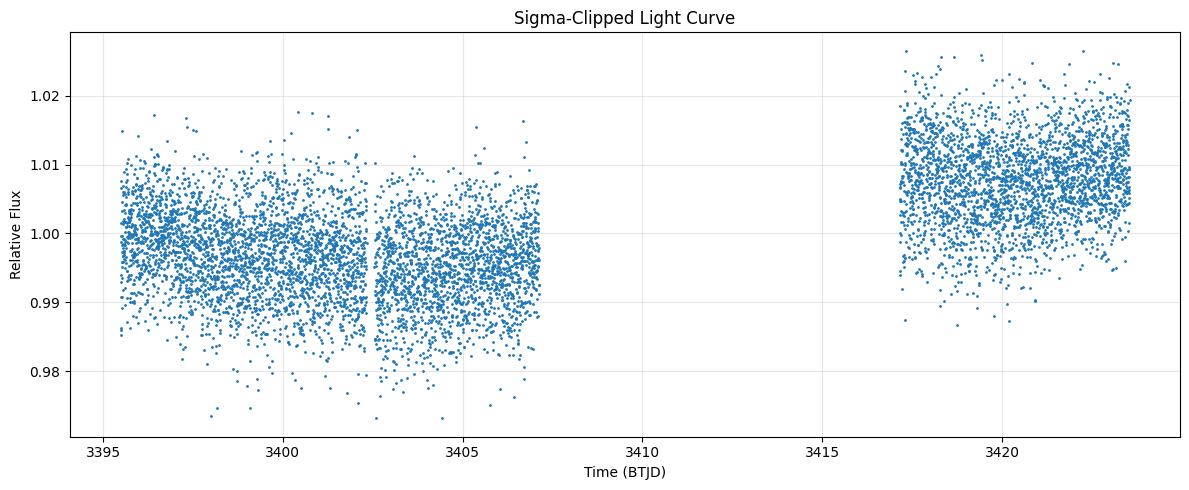

In [ ]:
clean_lc = normalized_lc.sigma_clip()

clean_lc.statistics()

clean_lc.plot(
    title="Sigma-Clipped Light Curve",
    ylabel="Relative Flux"
)

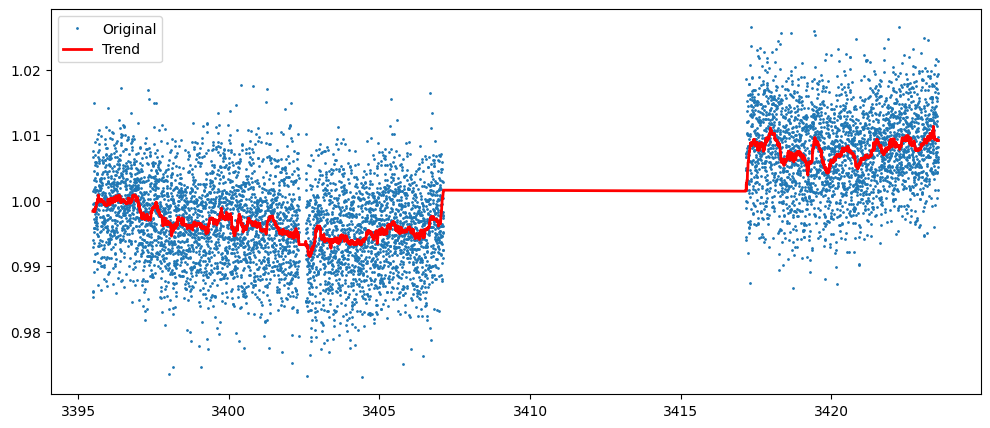

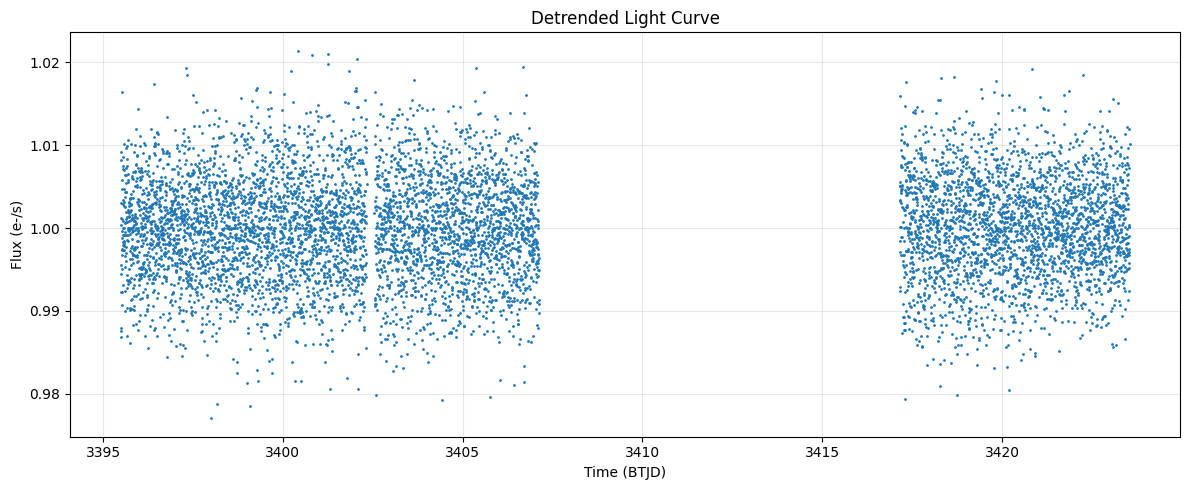

In [ ]:
detrended_lc, trend = clean_lc.detrend(window=101)

plt.figure(figsize=(12,5))
plt.plot(clean_lc.time, clean_lc.flux, ".", ms=2, label="Original")
plt.plot(clean_lc.time, trend, "r", lw=2, label="Trend")
plt.legend()
plt.show()

detrended_lc.plot(title="Detrended Light Curve")

In [ ]:
print(clean_lc.statistics())
print(detrended_lc.statistics())

Number of points : 7684
Mean flux        : 1.000389
Median flux      : 1.000000
Std deviation    : 0.008396
Minimum flux     : 0.973137
Maximum flux     : 1.026541
None
Number of points : 7684
Mean flux        : 0.999969
Median flux      : 1.000000
Std deviation    : 0.006160
Minimum flux     : 0.977025
Maximum flux     : 1.021414
None


In [ ]:
from astropy.timeseries import BoxLeastSquares

time = detrended_lc.time
flux = detrended_lc.flux
flux_err = detrended_lc.flux_error

In [ ]:
bls = BoxLeastSquares(
    time,
    flux,
    dy=flux_err
)

In [ ]:
import numpy as np

periods = np.linspace(0.5, 20, 5000)

durations = np.linspace(0.02, 0.25, 40)

In [ ]:
bls_result = bls.power(
    periods,
    durations
)

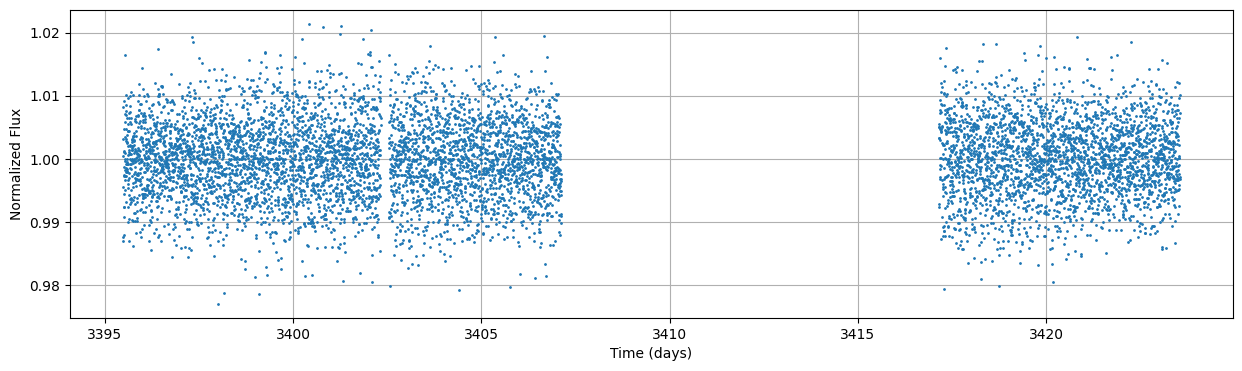

In [ ]:
plt.figure(figsize=(15,4))

plt.plot(
    detrended_lc.time,
    detrended_lc.flux,
    ".",
    ms=2
)

plt.xlabel("Time (days)")
plt.ylabel("Normalized Flux")
plt.grid(True)
plt.show()

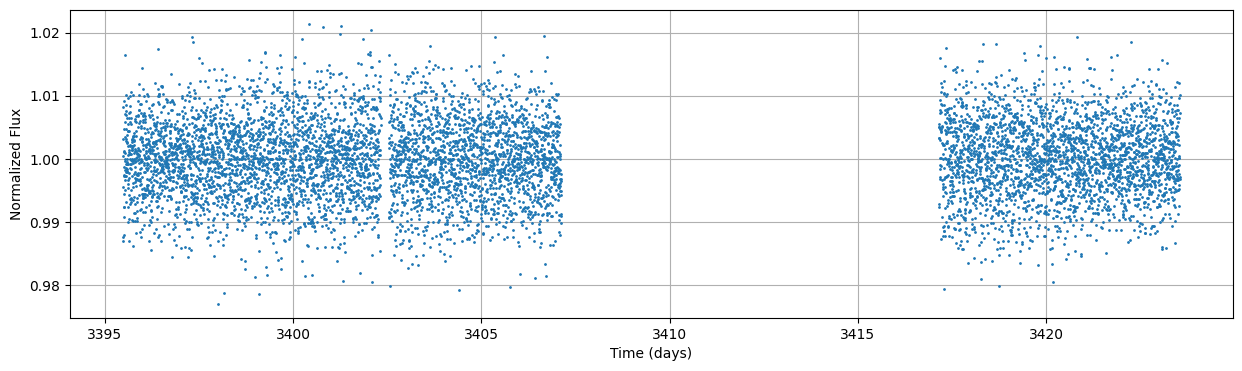

In [ ]:
plt.figure(figsize=(15,4))

plt.plot(
    detrended_lc.time,
    detrended_lc.flux,
    ".",
    ms=2
)

plt.xlabel("Time (days)")
plt.ylabel("Normalized Flux")
plt.grid(True)
plt.show()

In [ ]:
best = np.argmax(bls_result.power)

best_period = bls_result.period[best]
best_duration = bls_result.duration[best]
best_t0 = bls_result.transit_time[best]

In [ ]:
print(f"Best period   : {best_period:.6f} d")
print(f"Best duration : {best_duration:.6f} d")
print(f"Transit time  : {best_t0:.6f}")
print(f"BLS power     : {bls_result.power[best]:.4f}")

Best period   : 6.374575 d
Best duration : 0.020000 d
Transit time  : 3398.725193
BLS power     : 13.5650


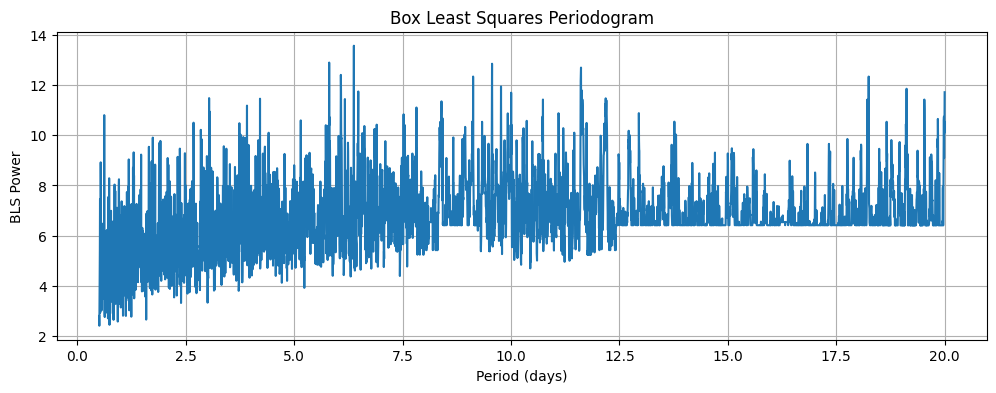

In [ ]:
plt.figure(figsize=(12,4))

plt.plot(
    bls_result.period,
    bls_result.power
)

plt.xlabel("Period (days)")
plt.ylabel("BLS Power")
plt.title("Box Least Squares Periodogram")

plt.grid(True)
plt.show()

In [ ]:
folded = detrended_lc.fold(
    period=best_period,
    t0=best_t0
)
phase = folded.time
flux = folded.flux

bins = np.linspace(0, 1, 201)

digitized = np.digitize(phase, bins)

bin_phase = []
bin_flux = []

for i in range(1, len(bins)):
    mask = digitized == i

    if np.any(mask):
        bin_phase.append(np.mean(phase[mask]))
        bin_flux.append(np.mean(flux[mask]))

bin_phase = np.array(bin_phase)
bin_flux = np.array(bin_flux)

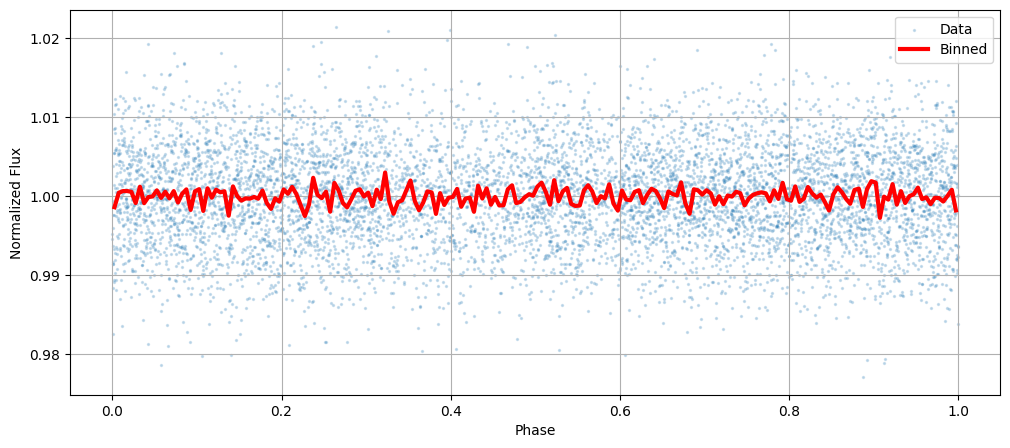

In [ ]:
plt.figure(figsize=(12,5))

plt.scatter(
    phase,
    flux,
    s=2,
    alpha=0.2,
    label="Data"
)

plt.plot(
    bin_phase,
    bin_flux,
    color="red",
    lw=3,
    label="Binned"
)

plt.xlabel("Phase")
plt.ylabel("Normalized Flux")
plt.legend()
plt.grid(True)
plt.show()

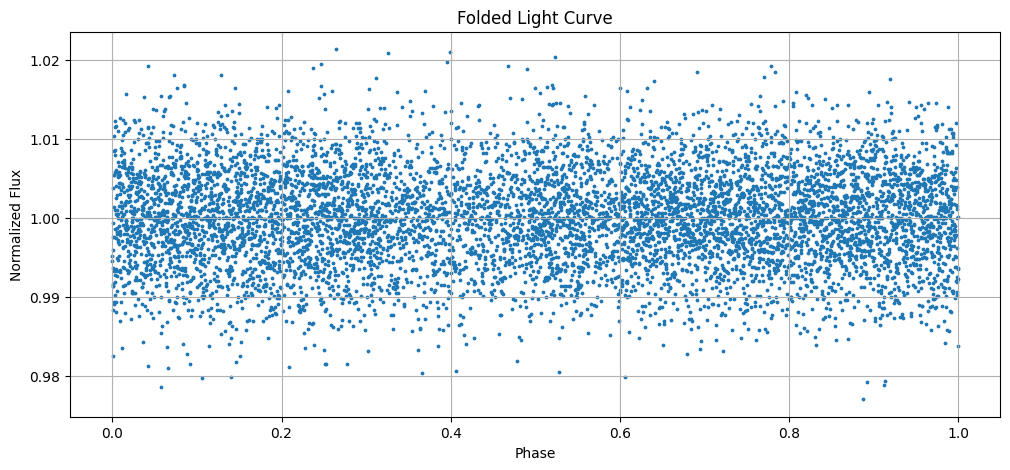

In [ ]:
plt.figure(figsize=(12,5))

plt.scatter(
    folded.time,
    folded.flux,
    s=3
)

plt.xlabel("Phase")
plt.ylabel("Normalized Flux")
plt.title("Folded Light Curve")

plt.grid(True)
plt.show()

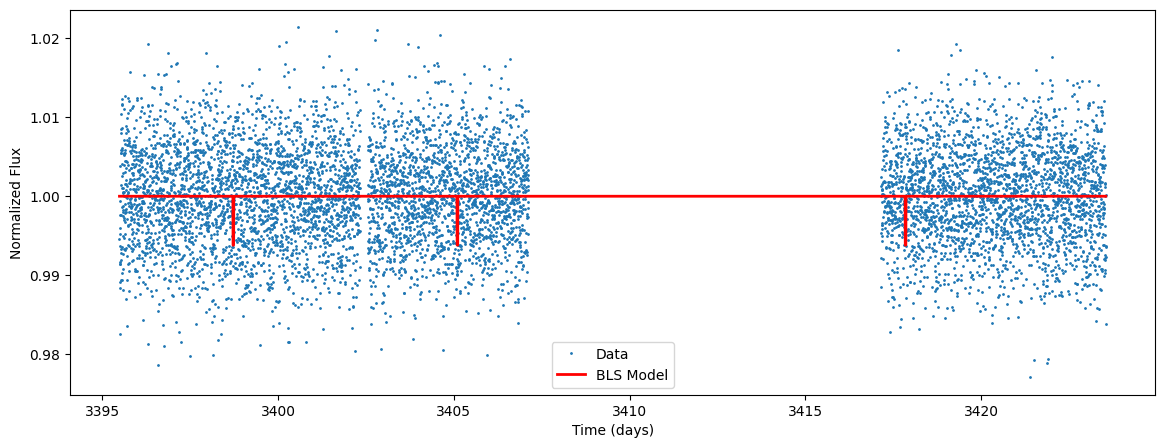

In [ ]:
model = bls.model(
    time,
    best_period,
    best_duration,
    best_t0
)

plt.figure(figsize=(14,5))

plt.plot(time, flux, ".", ms=2, label="Data")
plt.plot(time, model, "r", lw=2, label="BLS Model")

plt.legend()
plt.xlabel("Time (days)")
plt.ylabel("Normalized Flux")
plt.show()

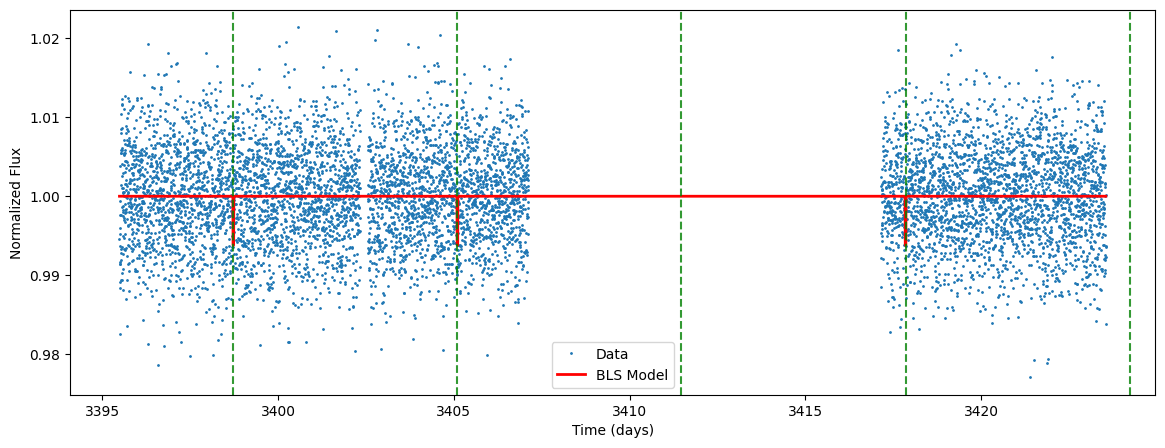

In [ ]:
period = best_period

# Shift t0 to the first transit within the data range
first_transit = best_t0 + np.ceil((time.min() - best_t0) / period) * period

# Generate all transit times
transit_times = np.arange(first_transit, time.max() + period, period)

plt.figure(figsize=(14, 5))
plt.plot(time, flux, ".", ms=2, label="Data")
plt.plot(time, model, "r", lw=2, label="BLS Model")

for t in transit_times:
    plt.axvline(t, color="green", linestyle="--", alpha=0.8)

plt.xlabel("Time (days)")
plt.ylabel("Normalized Flux")
plt.legend()
plt.show()